In [3]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
def normal_box_muller(mu, var, n=1):
    """
    Genera n muestras de N(mu, var) usando Box-Muller.
    """
    u1 = np.random.uniform(0.0, 1.0, size=n)
    u2 = np.random.uniform(0.0, 1.0, size=n)

    z = np.cos(2 * np.pi * u1) * np.sqrt(-2 * np.log(u2))
    x = mu + np.sqrt(var) * z

    return float(x[0]) if n == 1 else x

In [ ]:
def normalizar_angulo(theta):
    """
    Lleva cualquier ángulo al rango [-π, π]
    """
    return (theta + np.pi) % (2 * np.pi) - np.pi

In [ ]:
def modelo_movimiento_odometria(x_t, u_t, alpha):
    """
    Implementa el modelo de movimiento basado en odometría con ruido gaussiano.
    """
    x, y, theta = x_t
    delta_r1, delta_r2, delta_t = u_t
    alpha1, alpha2, alpha3, alpha4 = alpha

    var_r1 = alpha1 * (delta_r1 ** 2) + alpha2 * (delta_t ** 2)
    var_t  = alpha3 * (delta_t ** 2) + alpha4 * (delta_r1 ** 2 + delta_r2 ** 2)
    var_r2 = alpha1 * (delta_r2 ** 2) + alpha2 * (delta_t ** 2)

    ruido_r1 = normal_box_muller(0, var_r1, 1)
    ruido_t  = normal_box_muller(0, var_t,  1)
    ruido_r2 = normal_box_muller(0, var_r2, 1)

    delta_r1_hat = delta_r1 - ruido_r1
    delta_t_hat  = delta_t  - ruido_t
    delta_r2_hat = delta_r2 - ruido_r2

    x_nuevo     = x + delta_t_hat * np.cos(theta + delta_r1_hat)
    y_nuevo     = y + delta_t_hat * np.sin(theta + delta_r1_hat)
    theta_nuevo = normalizar_angulo(theta + delta_r1_hat + delta_r2_hat)

    return np.array([x_nuevo, y_nuevo, theta_nuevo])

In [ ]:
def generar_muestras_odometria(N=5000):
    """
    Genera N muestras de la pose siguiente usando los parámetros:
        x_t = [2, 4, 0]
        u_t = [π/2, 0, 1]
        alpha = [0.1, 0.1, 0.01, 0.01]
    """
    x_t   = np.array([2.0, 4.0, 0.0])
    u_t   = np.array([np.pi / 2, 0.0, 1.0])
    alpha = np.array([0.1, 0.1, 0.01, 0.01])

    muestras = np.array([modelo_movimiento_odometria(x_t, u_t, alpha) for _ in range(N)])
    return muestras

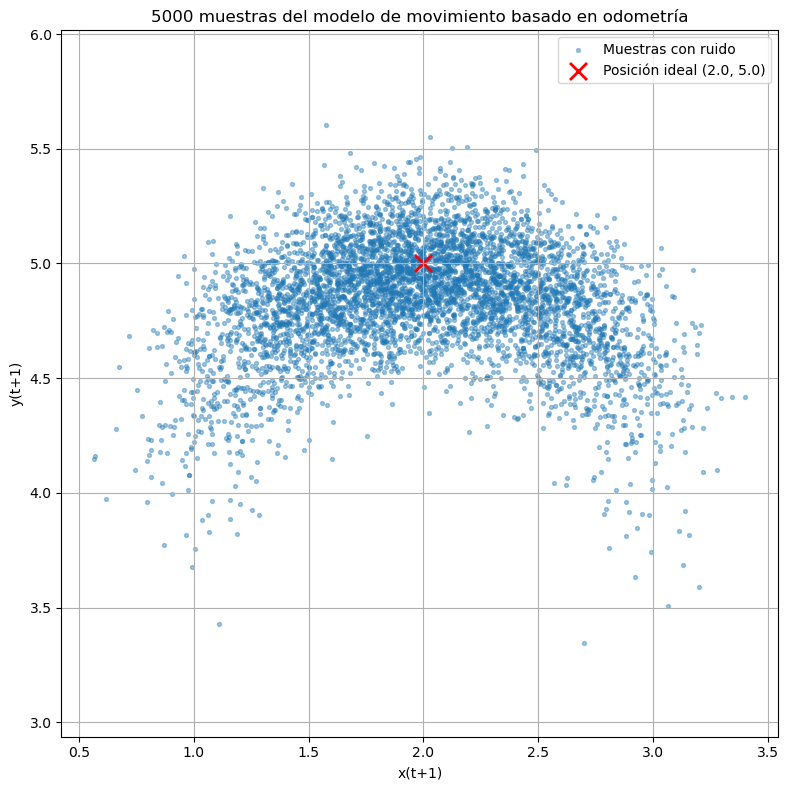

Media x: 1.9999  (ideal: 2.0)
Media y: 4.8385  (ideal: 5.0)


In [ ]:
if __name__ == "__main__":
    N = 5000
    muestras = generar_muestras_odometria(N)

    x_vals = muestras[:, 0]
    y_vals = muestras[:, 1]

    # Posición ideal: avanzar delta_t=1 con delta_r1=π/2 desde (2,4,0)
    # x' = 2 + 1*cos(0 + π/2) = 2 + 0 = 2
    # y' = 4 + 1*sin(0 + π/2) = 4 + 1 = 5
    x_ideal, y_ideal = 2.0, 5.0

    plt.figure(figsize=(8, 8))
    plt.scatter(x_vals, y_vals, s=8, alpha=0.4, label="Muestras con ruido")
    plt.scatter(x_ideal, y_ideal, marker='x', s=150, color='red',
                linewidths=2, label=f"Posición ideal ({x_ideal}, {y_ideal})")
    plt.xlabel("x(t+1)")
    plt.ylabel("y(t+1)")
    plt.title(f"{N} muestras del modelo de movimiento basado en odometría")
    plt.legend()
    plt.grid(True)
    plt.axis("equal")
    plt.tight_layout()
    plt.show()

    print(f"Media x: {np.mean(x_vals):.4f}  (ideal: {x_ideal})")
    print(f"Media y: {np.mean(y_vals):.4f}  (ideal: {y_ideal})")